# Reconhecendo dígitos escritos à mão com Keras, passo a passo

**Aula 4 · Deep Learning (DEPAI) · IASEG**

Neste notebook, vamos treinar uma rede que olha a imagem de um dígito escrito à mão (de 0 a 9) e diz qual é. É o mesmo caminho dos slides:

1. Preparar o ambiente;
2. Carregar o MNIST;
3. Olhar os dados: **uma imagem é uma tabela de números**;
4. Preparar os dados;
5. Uma rede densa, como ponto de partida;
6. Uma rede convolucional (CNN);
7. Ler as curvas do treino;
8. Avaliar no teste;
9. Fazer previsões;
10. Ver onde a rede erra;
11. Olhar por dentro da CNN: filtros e mapas;
12. Aumentação de dados;
13. Salvar e carregar o modelo;
14. Exercícios.

**Como usar.** Rodem uma célula de cada vez (`Shift + Enter`), **na ordem**, e leiam o texto antes de cada uma. Nas caixas **Palpite**, respondam antes de rodar a célula seguinte, como fazemos na aula.

**Tempo.** No Google Colab, tudo roda em poucos minutos, mesmo sem GPU. Com GPU (*Ambiente de execução → Alterar o tipo de ambiente de execução → GPU*), bem menos.

**As saídas que já aparecem** são de uma execução feita antes da aula. Quando vocês rodarem, os números vão mudar um pouco, por causa dos sorteios. As conclusões, não.

> **Um detalhe de nome.** O que vamos fazer aqui se chama **classificação**: a imagem tem um dígito só, e a rede diz qual. A **detecção** propriamente dita, que é achar *onde* está cada objeto e desenhar uma caixa em volta, é outra tarefa (o caso D da aula).

## Passo 1: preparar o ambiente

Três bibliotecas:

- **numpy**: contas com tabelas de números. Nossas imagens são tabelas;
- **matplotlib**: desenhar as imagens e os gráficos;
- **keras**: a biblioteca de redes neurais que usamos desde a Aula 2.

In [1]:
import numpy as np                 # tabelas de números
import matplotlib.pyplot as plt    # gráficos e imagens
import keras                       # redes neurais
from keras import layers           # as camadas: Dense, Conv2D, MaxPooling2D...

print("Versão do Keras:", keras.__version__)
print("Quem faz as contas por baixo (backend):", keras.backend.backend())

# Os pesos de uma rede começam SORTEADOS (Aula 4: "quem escolhe os pesos do filtro?").
# Fixar a "semente" faz os sorteios se repetirem: rodando de novo, os resultados ficam parecidos.
keras.utils.set_random_seed(42)

Versão do Keras: 3.15.1
Quem faz as contas por baixo (backend): torch


O **backend** é a biblioteca que faz as contas por baixo do Keras. No Colab, aparece `tensorflow`. A execução salva aqui usou `torch`. O código é o mesmo para os dois.

## Passo 2: carregar o MNIST

O **MNIST** tem 70.000 dígitos escritos à mão, cada um numa imagem de $28 \times 28$ pixels em tons de cinza. O Keras já traz a base pronta, e já dividida:

- **treino**: 60.000 imagens, para a rede aprender;
- **teste**: 10.000 imagens, guardadas para o fim.

Lembrete da Aula 2: o teste é como a prova final. Só olhamos para ele **uma vez**, depois de todas as escolhas feitas.

In [2]:
# Na primeira vez, o Keras baixa o arquivo (cerca de 11 MB)
(X_treino, y_treino), (X_teste, y_teste) = keras.datasets.mnist.load_data()

# X: as imagens. y: os rótulos (a resposta certa de cada imagem)
print("Imagens de treino:", X_treino.shape)    # (quantidade, altura, largura)
print("Rótulos de treino:", y_treino.shape)
print("Imagens de teste: ", X_teste.shape)
print("Rótulos de teste: ", y_teste.shape)
print()
print("Os 10 primeiros rótulos de treino:", y_treino[:10])

Imagens de treino: (60000, 28, 28)
Rótulos de treino: (60000,)
Imagens de teste:  (10000, 28, 28)
Rótulos de teste:  (10000,)

Os 10 primeiros rótulos de treino: [5 0 4 1 9 2 1 3 1 4]


**Lendo a saída**

- `(60000, 28, 28)`: são **60.000 tabelas**, cada uma com 28 linhas e 28 colunas;
- Os rótulos são **números inteiros** de 0 a 9, um por imagem. Por isso a perda vai ser `"sparse_categorical_crossentropy"` (Aula 3: rótulos inteiros levam o `sparse_`).

## Passo 3: olhar os dados

Antes de treinar qualquer coisa, **olhem os dados**. É assim que se descobrem rótulos errados, imagens estranhas e atalhos (Aula 2).

### 3.1 As primeiras imagens

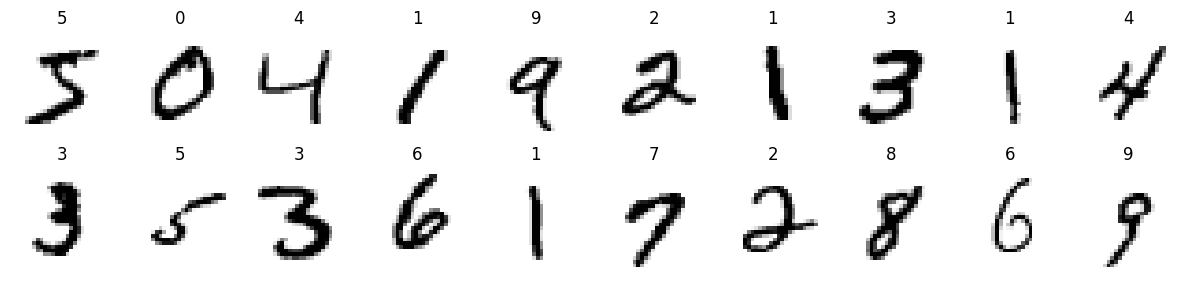

In [3]:
# As 20 primeiras imagens de treino, cada uma com o seu rótulo em cima
fig, eixos = plt.subplots(2, 10, figsize=(12, 3))
for i, eixo in enumerate(eixos.flat):
    eixo.imshow(X_treino[i], cmap="gray_r")   # gray_r: 0 fica branco (papel), 255 fica preto (tinta)
    eixo.set_title(str(y_treino[i]))
    eixo.axis("off")
plt.tight_layout()
plt.show()

### 3.2 Uma imagem é uma tabela de números

Para o computador, a primeira imagem acima não é “um 5”: é uma tabela de $28 \times 28 = 784$ números. **0 é papel e 255 é tinta.**

In [4]:
np.set_printoptions(linewidth=200)   # para a tabela caber numa linha só por linha da imagem
print("Rótulo desta imagem:", y_treino[0])
print(X_treino[0])

Rótulo desta imagem: 5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

Procurem o 5 no meio dos números: onde há tinta, os números são altos.

> **Palpite.** Qual é o menor número que aparece nas imagens? E o maior? Rodem a célula abaixo para conferir.

In [5]:
print("Menor número:", X_treino.min())
print("Maior número:", X_treino.max())
print("Tipo dos números:", X_treino.dtype)   # uint8: inteiros de 0 a 255

Menor número: 0
Maior número: 255
Tipo dos números: uint8


### 3.3 Quantas imagens de cada dígito?

Se um dígito fosse muito raro, a acurácia poderia enganar, como nos casos do trote e da arma (Aulas 3 e 4).

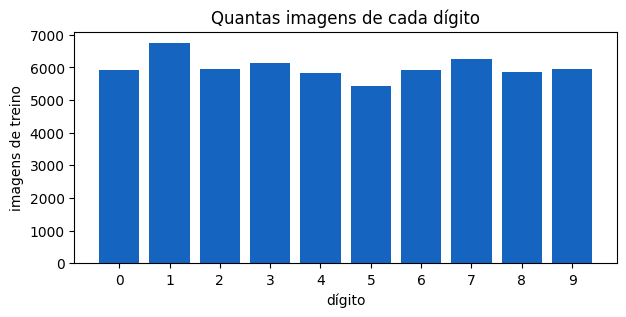

dígito 0: 5923 imagens
dígito 1: 6742 imagens
dígito 2: 5958 imagens
dígito 3: 6131 imagens
dígito 4: 5842 imagens
dígito 5: 5421 imagens
dígito 6: 5918 imagens
dígito 7: 6265 imagens
dígito 8: 5851 imagens
dígito 9: 5949 imagens


In [6]:
digitos, contagem = np.unique(y_treino, return_counts=True)

plt.figure(figsize=(7, 3))
plt.bar(digitos, contagem, color="#1565C0")
plt.xticks(digitos)
plt.xlabel("dígito")
plt.ylabel("imagens de treino")
plt.title("Quantas imagens de cada dígito")
plt.show()

for d, c in zip(digitos, contagem):
    print(f"dígito {d}: {c} imagens")

Entre 5.400 e 6.700 imagens por dígito: as classes estão **equilibradas**. Aqui, a acurácia (a fração de acertos) é uma boa medida.

## Passo 4: preparar os dados

Dois ajustes nas imagens:

1. **De 0–255 para 0–1**: dividir tudo por 255. A rede treina melhor com números pequenos (Aula 3);
2. **Acrescentar o canal**: uma `Conv2D` espera cada imagem como `(altura, largura, canais)`. Em cinza há **1 canal**; uma foto colorida teria 3 (R, G e B), como a placa da aula.

Os rótulos ficam como estão: inteiros de 0 a 9.

In [7]:
# 1) De 0-255 para 0-1
X_treino = X_treino.astype("float32") / 255
X_teste = X_teste.astype("float32") / 255

# 2) Acrescentar o canal: (60000, 28, 28) vira (60000, 28, 28, 1)
X_treino = X_treino.reshape(len(X_treino), 28, 28, 1)
X_teste = X_teste.reshape(len(X_teste), 28, 28, 1)

print("Treino:", X_treino.shape, "| menor:", X_treino.min(), "| maior:", X_treino.max())
print("Teste: ", X_teste.shape)

Treino: (60000, 28, 28, 1) | menor: 0.0 | maior: 1.0
Teste:  (10000, 28, 28, 1)


**E a validação?** No `fit`, vamos usar `validation_split=0.1`: o Keras separa 10% do treino (6.000 imagens) para a validação, e treina com as outras 54.000. O teste continua guardado.

> **Palpite.** Com 54.000 imagens de treino e lote de 128 (`batch_size=128`), quantas atualizações dos pesos há em cada época? (Aula 3: exemplos $\div$ lote, arredondando para cima.) A resposta aparece na saída do `fit`, logo abaixo.

## Passo 5: a primeira rede, uma rede densa (o ponto de partida)

Antes da CNN, uma rede **densa**, como as das Aulas 2 e 3. Ela vira a nossa **referência**: a CNN só vale a pena se for melhor que ela.

- `Flatten`: “achata” a imagem. As 28 linhas, uma depois da outra, viram uma fila de 784 números;
- `Dense(128, activation="relu")`: uma camada oculta com 128 neurônios e ReLU;
- `Dense(10, activation="softmax")`: a saída, com **um neurônio por dígito**. A softmax transforma as 10 pontuações em probabilidades que somam 1 (Aula 3).

In [8]:
densa = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),           # cada imagem: 28 x 28, 1 canal
    layers.Flatten(),                         # 28 x 28 x 1 -> fila de 784 números
    layers.Dense(128, activation="relu"),     # camada oculta
    layers.Dense(10, activation="softmax"),   # 10 probabilidades, uma por dígito
], name="densa")

densa.summary()

Model: "densa"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 101,770 (397.54 KB)

Trainable params: 101,770 (397.54 KB)

Non-trainable params: 0 (0.00 B)

**Conferindo os parâmetros (Aula 2: entradas $+ 1$, vezes neurônios)**

| Camada | Conta | Parâmetros |
|---|---|---|
| `Dense(128)`, com 784 entradas | $(784 + 1) \times 128$ | 100.480 |
| `Dense(10)`, com 128 entradas | $(128 + 1) \times 10$ | 1.290 |
| **total** | | **101.770** |

Agora, compilar e treinar. É a receita da Aula 3:

- `optimizer="adam"`: Adam, com a taxa padrão de 0,001;
- `loss="sparse_categorical_crossentropy"`: multiclasse com rótulos inteiros;
- `metrics=["accuracy"]`: a acurácia, para nós lermos;
- `epochs=5`: 5 voltas pelos dados de treino; `batch_size=128`: 128 imagens por atualização.

In [9]:
densa.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

historico_densa = densa.fit(X_treino, y_treino,
                            epochs=5,
                            batch_size=128,
                            validation_split=0.1,   # 10% do treino para a validação
                            verbose=2)              # uma linha por época

Epoch 1/5


422/422 - 5s - 12ms/step - accuracy: 0.8922 - loss: 0.3862 - val_accuracy: 0.9552 - val_loss: 0.1776


Epoch 2/5


422/422 - 5s - 11ms/step - accuracy: 0.9474 - loss: 0.1828 - val_accuracy: 0.9678 - val_loss: 0.1238


Epoch 3/5


422/422 - 5s - 11ms/step - accuracy: 0.9626 - loss: 0.1304 - val_accuracy: 0.9737 - val_loss: 0.1008


Epoch 4/5


422/422 - 5s - 11ms/step - accuracy: 0.9705 - loss: 0.1007 - val_accuracy: 0.9755 - val_loss: 0.0929


Epoch 5/5


422/422 - 5s - 12ms/step - accuracy: 0.9767 - loss: 0.0807 - val_accuracy: 0.9780 - val_loss: 0.0828


**Lendo a saída do `fit`** (Aula 3)

- `422/422`: são 422 lotes por época, ou seja, 422 atualizações dos pesos ($54.000 \div 128 = 421{,}9$, arredondado para cima). Era o palpite do passo 4;
- `loss` e `accuracy`: no treino. `val_loss` e `val_accuracy`: na validação.

Por enquanto, guardamos a rede densa. Vamos compará-la com a CNN no teste, no passo 8.

## Passo 6: a rede convolucional (CNN)

A rede densa trata cada pixel como uma entrada solta: ela não sabe quem é vizinho de quem. A CNN olha **pedaços pequenos** da imagem com **filtros** que percorrem a imagem inteira (os slides da convolução).

A arquitetura da aula, camada por camada:

| Camada | O que faz | Tamanho da saída |
|---|---|---|
| entrada | o dígito | $28 \times 28 \times 1$ |
| `Conv2D(32, 3)` | 32 filtros $3 \times 3$; o mapa perde 2 de altura e de largura | $26 \times 26 \times 32$ |
| `MaxPooling2D(2)` | fica com o maior de cada bloco $2 \times 2$ | $13 \times 13 \times 32$ |
| `Conv2D(64, 3)` | 64 filtros, cada um olhando os 32 mapas | $11 \times 11 \times 64$ |
| `MaxPooling2D(2)` | $11 \div 2 = 5{,}5$, arredondado para baixo | $5 \times 5 \times 64$ |
| `Flatten` | achata: $5 \times 5 \times 64$ | $1.600$ |
| `Dense(10)` softmax | decide: 10 probabilidades | $10$ |

> **Palpite.** Quantos parâmetros tem a primeira `Conv2D(32, 3)`? Use a regra da aula: (altura $\times$ largura $\times$ canais que entram $+ 1$) $\times$ filtros.

In [10]:
cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),   # 32 filtros 3x3 -> 26 x 26 x 32
    layers.MaxPooling2D(2),                    # blocos 2x2     -> 13 x 13 x 32
    layers.Conv2D(64, 3, activation="relu"),   # 64 filtros 3x3 -> 11 x 11 x 64
    layers.MaxPooling2D(2),                    #                -> 5 x 5 x 64
    layers.Flatten(),                          #                -> 1.600 números
    layers.Dense(10, activation="softmax"),    # 10 probabilidades
], name="cnn")

cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 34,826 (136.04 KB)

Trainable params: 34,826 (136.04 KB)

Non-trainable params: 0 (0.00 B)

**Conferindo os parâmetros**

| Camada | Conta | Parâmetros |
|---|---|---|
| `Conv2D(32, 3)` | $(3 \times 3 \times 1 + 1) \times 32$ | 320 (o palpite) |
| `MaxPooling2D` | não tem pesos | 0 |
| `Conv2D(64, 3)` | $(3 \times 3 \times 32 + 1) \times 64$ | 18.496 |
| `Flatten` | não tem pesos | 0 |
| `Dense(10)` | $(1.600 + 1) \times 10$ | 16.010 |
| **total** | | **34.826** |

São **3 vezes menos** parâmetros que a rede densa. Será que ela acerta menos?

O `compile` e o `fit` são **exatamente os mesmos** da rede densa: só a arquitetura mudou. A CNN demora mais por época, porque cada filtro passa pela imagem inteira.

In [11]:
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

historico_cnn = cnn.fit(X_treino, y_treino,
                        epochs=5,
                        batch_size=128,
                        validation_split=0.1,
                        verbose=2)

Epoch 1/5


422/422 - 46s - 108ms/step - accuracy: 0.9162 - loss: 0.2952 - val_accuracy: 0.9787 - val_loss: 0.0793


Epoch 2/5


422/422 - 42s - 99ms/step - accuracy: 0.9755 - loss: 0.0793 - val_accuracy: 0.9822 - val_loss: 0.0615


Epoch 3/5


422/422 - 25s - 59ms/step - accuracy: 0.9823 - loss: 0.0587 - val_accuracy: 0.9855 - val_loss: 0.0487


Epoch 4/5


422/422 - 25s - 59ms/step - accuracy: 0.9848 - loss: 0.0480 - val_accuracy: 0.9893 - val_loss: 0.0421


Epoch 5/5


422/422 - 25s - 60ms/step - accuracy: 0.9872 - loss: 0.0414 - val_accuracy: 0.9882 - val_loss: 0.0407


## Passo 7: ler as curvas do treino

O `fit` devolve o **histórico**: a perda e a acurácia de cada época, no treino e na validação. Desenhar as curvas é a forma de diagnosticar o treino (Aula 3, atividade “leia a curva”).

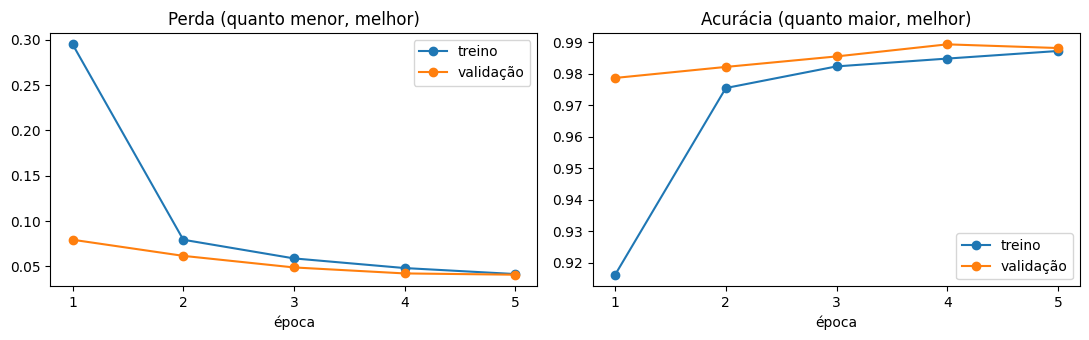

In [12]:
h = historico_cnn.history          # um dicionário: "loss", "accuracy", "val_loss", "val_accuracy"
epocas = range(1, len(h["loss"]) + 1)

fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(11, 3.5))

eixo1.plot(epocas, h["loss"], "o-", label="treino")
eixo1.plot(epocas, h["val_loss"], "o-", label="validação")
eixo1.set_title("Perda (quanto menor, melhor)")
eixo1.set_xlabel("época")
eixo1.legend()

eixo2.plot(epocas, h["accuracy"], "o-", label="treino")
eixo2.plot(epocas, h["val_accuracy"], "o-", label="validação")
eixo2.set_title("Acurácia (quanto maior, melhor)")
eixo2.set_xlabel("época")
eixo2.legend()

for eixo in (eixo1, eixo2):
    eixo.set_xticks(list(epocas))     # só épocas inteiras no eixo
plt.tight_layout()
plt.show()

**Como ler**

- As duas perdas **caem juntas**: a rede está aprendendo e ainda não sobreajustou;
- Se a perda de validação começasse a **subir** enquanto a de treino cai, seria **sobreajuste** (Aula 2). O remédio da Aula 3 é a parada antecipada, `EarlyStopping` (exercício 1);
- No começo, a validação pode ficar até **melhor** que o treino. É normal: a acurácia de treino é a média durante a época, enquanto a rede ainda está aprendendo; a de validação é medida no fim da época.

## Passo 8: avaliar no teste, uma vez só, no fim

Agora sim: as duas redes, nas 10.000 imagens de teste, que **nenhuma delas viu**.

In [13]:
perda_d, acerto_d = densa.evaluate(X_teste, y_teste, verbose=0)
perda_c, acerto_c = cnn.evaluate(X_teste, y_teste, verbose=0)

erros_d = round((1 - acerto_d) * len(X_teste))
erros_c = round((1 - acerto_c) * len(X_teste))

print("Rede densa: parâmetros =", densa.count_params(), "| acerto =", round(100 * acerto_d, 1), "% | erros:", erros_d)
print("CNN:        parâmetros =", cnn.count_params(), " | acerto =", round(100 * acerto_c, 1), "% | erros:", erros_c)

Rede densa: parâmetros = 101770 | acerto = 97.3 % | erros: 269
CNN:        parâmetros = 34826  | acerto = 98.6 % | erros: 137


Com **3 vezes menos parâmetros**, a CNN erra mais ou menos **a metade** do que a rede densa erra. Na execução salva neste notebook: 269 erros da densa contra 137 da CNN. É o resultado da aula, refeito por vocês. Ao rodar de novo, os números mudam um pouco, por causa dos sorteios, mas a diferença continua.

## Passo 9: fazer previsões

`predict` devolve, para cada imagem, as **10 probabilidades** da softmax. A previsão é o dígito de **maior** probabilidade: `np.argmax`.

dígito 0: 0.00%
dígito 1: 0.00%
dígito 2: 0.00%
dígito 3: 0.00%
dígito 4: 0.00%
dígito 5: 0.00%
dígito 6: 0.00%
dígito 7: 100.00%
dígito 8: 0.00%
dígito 9: 0.00%
Soma: 1.0
Previsão (a maior): 7 | Rótulo certo: 7


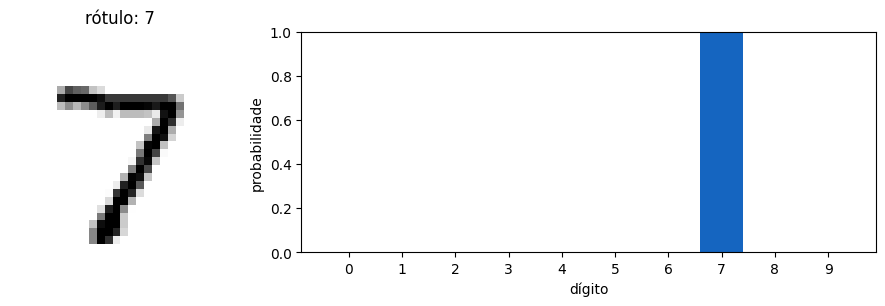

In [14]:
probabilidades = cnn.predict(X_teste[:1], verbose=0)[0]   # as 10 probabilidades da 1a imagem de teste

for digito, p in enumerate(probabilidades):
    print(f"dígito {digito}: {p:.2%}")
print("Soma:", round(float(probabilidades.sum()), 4))       # a softmax sempre soma 1 (Aula 3)
print("Previsão (a maior):", np.argmax(probabilidades), "| Rótulo certo:", y_teste[0])

fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"width_ratios": [1, 2.5]})
eixo1.imshow(X_teste[0, :, :, 0], cmap="gray_r")
eixo1.set_title(f"rótulo: {y_teste[0]}")
eixo1.axis("off")
eixo2.bar(range(10), probabilidades, color="#1565C0")
eixo2.set_xticks(range(10))
eixo2.set_xlabel("dígito")
eixo2.set_ylabel("probabilidade")
eixo2.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Nesta imagem, a rede está praticamente certa: quase 100% para o 7. No passo 10, vamos ver um dígito em que ela fica em dúvida.

Agora, várias de uma vez: 15 imagens de teste, com a previsão e a certeza da rede.

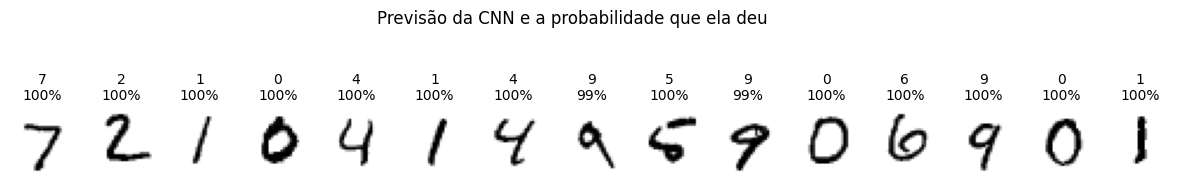

In [15]:
probs = cnn.predict(X_teste[:15], verbose=0)    # 15 linhas, 10 probabilidades em cada
previstos = np.argmax(probs, axis=1)             # o dígito de maior probabilidade, em cada linha

fig, eixos = plt.subplots(1, 15, figsize=(15, 2))
for i, eixo in enumerate(eixos):
    eixo.imshow(X_teste[i, :, :, 0], cmap="gray_r")
    eixo.set_title(f"{previstos[i]}\n{probs[i].max():.0%}", fontsize=10)
    eixo.axis("off")
plt.suptitle("Previsão da CNN e a probabilidade que ela deu", y=1.15)
plt.show()

## Passo 10: onde a rede erra

O número de acertos não diz **como** a rede erra. Olhar os erros é a análise de erros da Aula 2: dá pistas do que a rede está usando.

### 10.1 Os erros, um por um

Erros no teste: 137 de 10000


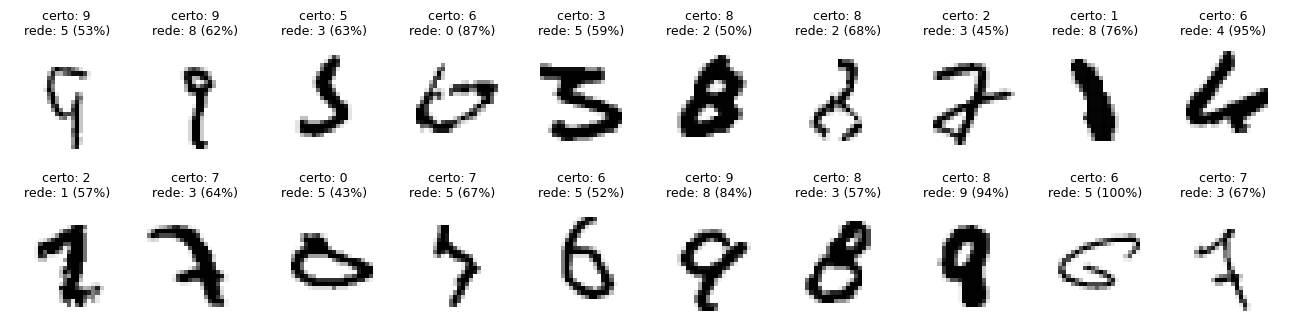

In [16]:
probs_teste = cnn.predict(X_teste, verbose=0)
previstos_teste = np.argmax(probs_teste, axis=1)

errados = np.where(previstos_teste != y_teste)[0]      # as posições das imagens erradas
print("Erros no teste:", len(errados), "de", len(y_teste))

fig, eixos = plt.subplots(2, 10, figsize=(13, 3.6))
for eixo, i in zip(eixos.flat, errados[:20]):
    eixo.imshow(X_teste[i, :, :, 0], cmap="gray_r")
    eixo.set_title(f"certo: {y_teste[i]}\nrede: {previstos_teste[i]} ({probs_teste[i].max():.0%})", fontsize=9)
    eixo.axis("off")
plt.tight_layout()
plt.show()

> **Para discutir.** Vocês acertariam todos esses? Vários erros são dígitos mal escritos, que até uma pessoa confundiria. Em alguns, a rede errou com muita certeza: esses são os que mais custam na perda (Aula 3, “errar com muita certeza custa caro”).

### 10.2 O dígito em que a rede ficou mais em dúvida

Procuramos a imagem de teste em que a **maior** das 10 probabilidades foi a menor de todas, ou seja, em que a rede teve menos certeza. Aqui se vê a softmax “dividindo a certeza” entre as classes (Aula 3).

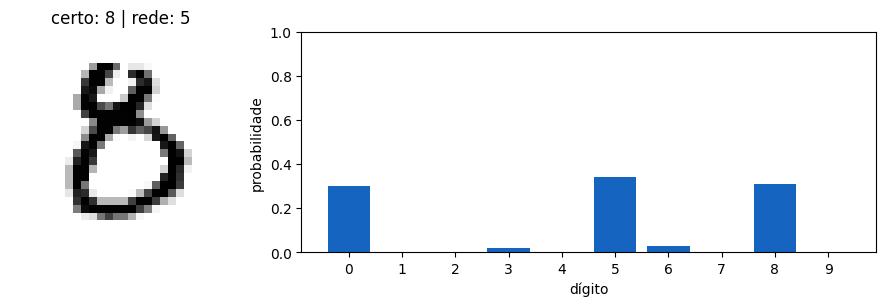

dígito 5: 34%
dígito 8: 31%
dígito 0: 30%


In [17]:
certeza = probs_teste.max(axis=1)        # a maior probabilidade de cada imagem
i = int(np.argmin(certeza))              # a imagem com a menor certeza

fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={"width_ratios": [1, 2.5]})
eixo1.imshow(X_teste[i, :, :, 0], cmap="gray_r")
eixo1.set_title(f"certo: {y_teste[i]} | rede: {previstos_teste[i]}")
eixo1.axis("off")
eixo2.bar(range(10), probs_teste[i], color="#1565C0")
eixo2.set_xticks(range(10))
eixo2.set_xlabel("dígito")
eixo2.set_ylabel("probabilidade")
eixo2.set_ylim(0, 1)
plt.tight_layout()
plt.show()

for digito in np.argsort(-probs_teste[i])[:3]:   # as 3 maiores probabilidades
    print(f"dígito {digito}: {probs_teste[i, digito]:.0%}")

Na execução salva aqui, a rede dividiu a certeza em três partes quase iguais, entre 5, 8 e 0, e nenhuma passou de 35%. Num sistema de verdade, um caso assim não deveria ser decidido pela rede: dá para mandar para **conferência humana** toda imagem em que a maior probabilidade ficar abaixo de um limite, por exemplo 90%.

### 10.3 A matriz de confusão: quem é confundido com quem

Uma tabela $10 \times 10$: a linha é o dígito certo, a coluna é o que a rede disse. A diagonal são os acertos; fora dela, os erros.

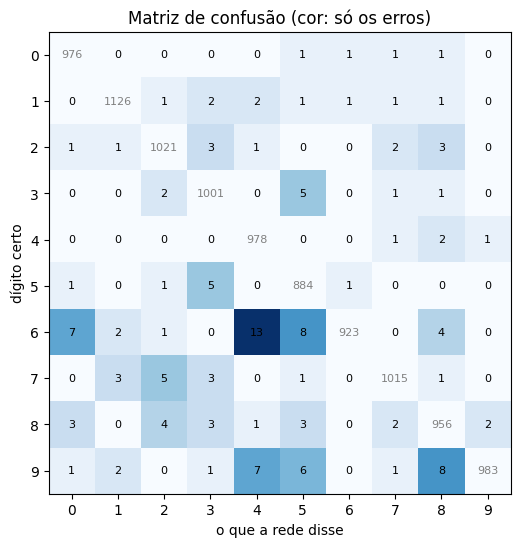

 13 vezes: era 6, a rede disse 4
  8 vezes: era 9, a rede disse 8
  8 vezes: era 6, a rede disse 5
  7 vezes: era 9, a rede disse 4
  7 vezes: era 6, a rede disse 0


In [18]:
# Contar cada par (certo, previsto)
matriz = np.zeros((10, 10), dtype=int)
for certo, previsto in zip(y_teste, previstos_teste):
    matriz[certo, previsto] += 1

# Para enxergar os erros, a cor mostra só o que está FORA da diagonal
fora = matriz.copy()
np.fill_diagonal(fora, 0)

plt.figure(figsize=(7, 6))
plt.imshow(fora, cmap="Blues")
for i in range(10):
    for j in range(10):
        plt.text(j, i, matriz[i, j], ha="center", va="center", fontsize=8,
                 color="black" if i != j else "gray")
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("o que a rede disse")
plt.ylabel("dígito certo")
plt.title("Matriz de confusão (cor: só os erros)")
plt.show()

# As 5 confusões mais comuns
pares = [(fora[i, j], i, j) for i in range(10) for j in range(10) if fora[i, j] > 0]
for n, i, j in sorted(pares, reverse=True)[:5]:
    print(f"{n:3d} vezes: era {i}, a rede disse {j}")

**Como ler.** A linha do 6, por exemplo, mostra para onde foram os 6 que a rede errou. Na execução salva aqui, as confusões mais comuns foram 6 $\to$ 4, 9 $\to$ 8 e 6 $\to$ 5. Ao rodar de novo, os pares mudam um pouco, mas costumam ser de dígitos com traços parecidos: o laço de baixo do 6 e do 5, a haste do 4 e do 9, os dois laços do 8 e do 9.

> **Para discutir.** Se essa rede lesse dígitos em formulários de ocorrência, que confusão seria mais grave? Como vocês tratariam os casos em que a rede tem pouca certeza? (Pista: o passo 10.2.)

## Passo 11: por dentro da CNN

### 11.1 Os filtros da primeira camada

A primeira `Conv2D` tem 32 filtros $3 \times 3$. Eles começaram **sorteados**, e o treino os ajustou (slide “Quem escolhe os pesos do filtro?”). Azul: peso positivo; vermelho: negativo.

Forma dos pesos: (3, 3, 1, 32) | bias: (32,)


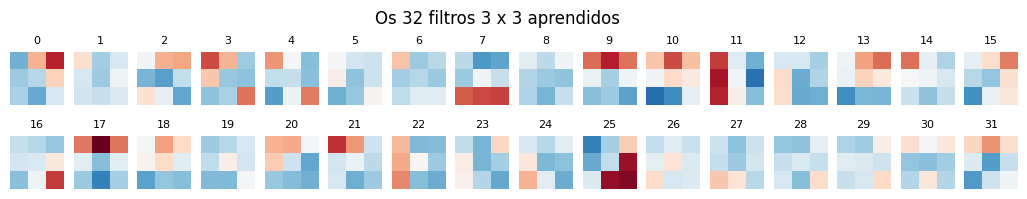

Os 9 pesos do filtro 0:
[[ 0.23 -0.17 -0.37]
 [ 0.18  0.14 -0.11]
 [ 0.16  0.24  0.08]]


In [19]:
pesos, bias = cnn.layers[0].get_weights()     # pesos: 3 x 3 x 1 canal x 32 filtros
print("Forma dos pesos:", pesos.shape, "| bias:", bias.shape)

limite = np.abs(pesos).max()
fig, eixos = plt.subplots(2, 16, figsize=(13, 2))
for k, eixo in enumerate(eixos.flat):
    eixo.imshow(pesos[:, :, 0, k], cmap="RdBu", vmin=-limite, vmax=limite)
    eixo.set_title(str(k), fontsize=8)
    eixo.axis("off")
plt.suptitle("Os 32 filtros 3 x 3 aprendidos", y=1.05)
plt.show()

print("Os 9 pesos do filtro 0:")
print(np.round(pesos[:, :, 0, 0], 2))

### 11.2 Os mapas: o que cada filtro “vê” num dígito

Vamos montar um modelo que vai da entrada **até a primeira** `Conv2D`, e passar uma imagem por ele. Saem 32 mapas de $26 \times 26$, um por filtro. Escuro: o filtro acendeu ali (slide “Vários filtros, vários mapas”).

Forma dos mapas: (26, 26, 32)


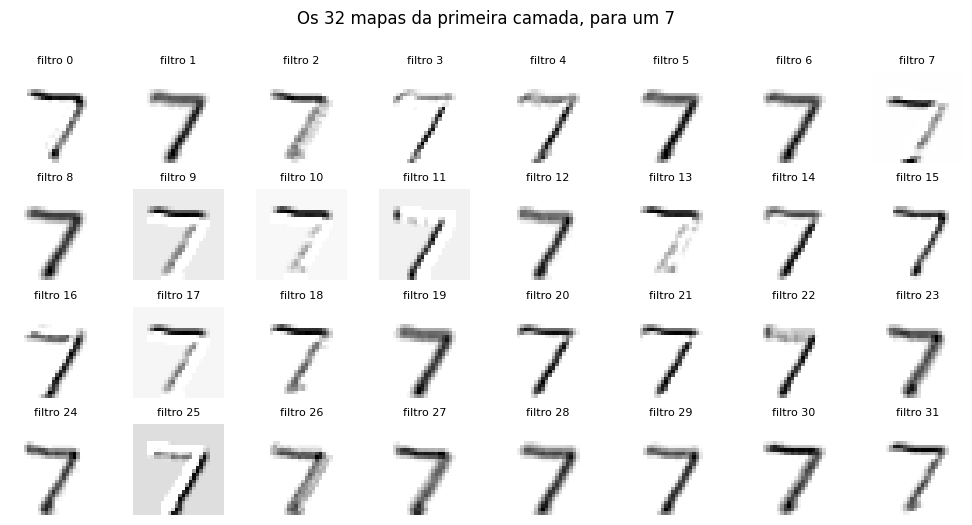

In [20]:
# Um modelo "sonda": mesma entrada da CNN, saída na primeira camada
sonda = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[0].output)

imagem = X_teste[:1]                                 # a primeira imagem de teste (um 7)
mapas = keras.ops.convert_to_numpy(sonda(imagem))[0] # 26 x 26 x 32
print("Forma dos mapas:", mapas.shape)

fig, eixos = plt.subplots(4, 8, figsize=(10, 5.2))
for k, eixo in enumerate(eixos.flat):
    eixo.imshow(mapas[:, :, k], cmap="gray_r")
    eixo.set_title(f"filtro {k}", fontsize=8)
    eixo.axis("off")
plt.suptitle("Os 32 mapas da primeira camada, para um 7", y=1.0)
plt.tight_layout()
plt.show()

Muitos mapas ainda se parecem com o 7 inteiro: a primeira camada só vê pedaços $3 \times 3$, traços simples. Mas reparem nas diferenças:

- alguns destacam mais o traço de cima, outros mais a diagonal;
- outros marcam só o **contorno** do traço (as bordas, como o filtro de borda da aula);
- e alguns acendem no **papel** em volta do traço: o fundo fica cinza e o traço, claro.

### 11.3 Os mapas da segunda camada

Na segunda `Conv2D`, cada número já resume um pedaço maior da imagem (slide “Por que encolher?”). Os mapas ficam menores, $11 \times 11$, e cada um fica com **uma parte** do dígito.

Forma dos mapas: (11, 11, 64)


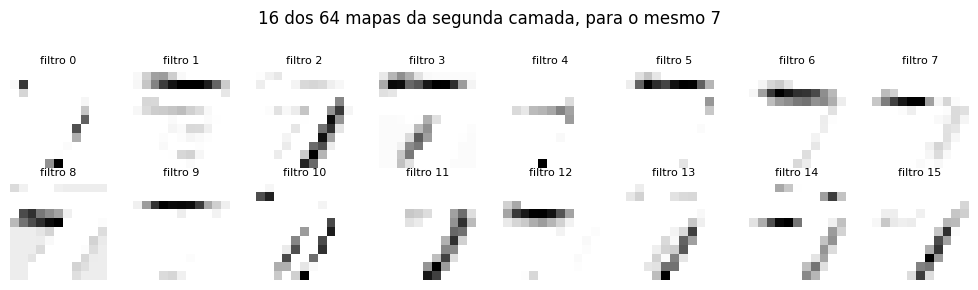

In [21]:
# A mesma ideia, agora com a saída na segunda Conv2D (a camada 2: 0 = Conv2D, 1 = MaxPooling2D, 2 = Conv2D)
sonda2 = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[2].output)
mapas2 = keras.ops.convert_to_numpy(sonda2(imagem))[0]   # 11 x 11 x 64
print("Forma dos mapas:", mapas2.shape)

fig, eixos = plt.subplots(2, 8, figsize=(10, 2.8))
for k, eixo in enumerate(eixos.flat):          # os 16 primeiros dos 64 mapas
    eixo.imshow(mapas2[:, :, k], cmap="gray_r")
    eixo.set_title(f"filtro {k}", fontsize=8)
    eixo.axis("off")
plt.suptitle("16 dos 64 mapas da segunda camada, para o mesmo 7", y=1.02)
plt.tight_layout()
plt.show()

Agora os mapas já não desenham o 7 inteiro: uns ficam só com o traço de cima, outros só com a diagonal. É a hierarquia da aula: **traços, depois partes, depois o dígito**.

## Passo 12: aumentação de dados

Na aula: variações das imagens de treino que **não mudam a resposta**. No Keras, são camadas que sorteiam uma variação nova a cada vez:

- `RandomRotation(0.05)`: gira até 5% de uma volta (18°). **Pouco**: girar 180° transformaria um 6 num 9;
- `RandomZoom(0.1)`: aproxima ou afasta até 10%;
- `RandomTranslation(0.1, 0.1)`: desloca até 10% na vertical e na horizontal.

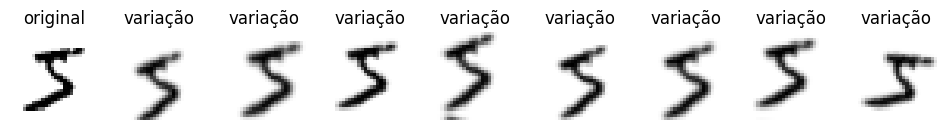

In [22]:
aumentacao = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

digito = X_treino[:1]   # a primeira imagem de treino (um 5)

fig, eixos = plt.subplots(1, 9, figsize=(12, 1.8))
eixos[0].imshow(digito[0, :, :, 0], cmap="gray_r")
eixos[0].set_title("original")
for eixo in eixos[1:]:
    # training=True: as camadas de aumentação só agem no treino; aqui, forçamos para ver
    variacao = keras.ops.convert_to_numpy(aumentacao(digito, training=True))
    eixo.imshow(variacao[0, :, :, 0], cmap="gray_r")
    eixo.set_title("variação")
for eixo in eixos:
    eixo.axis("off")
plt.show()

Para treinar com aumentação, basta colocar `aumentacao` como a primeira “camada” da CNN, logo depois do `keras.Input`. No `fit`, ela sorteia variações novas a cada época. No `evaluate` e no `predict`, deixa as imagens como estão. Com as 60.000 imagens do MNIST, o ganho é pequeno; com poucas imagens, é grande (exercício 6).

## Passo 13: salvar e carregar o modelo

Treinar demora; usar, não. Depois de treinada, a rede vira um arquivo `.keras` com a arquitetura e os pesos. Dá para carregar em outro computador e prever sem treinar de novo.

In [23]:
cnn.save("cnn_mnist.keras")                          # salva arquitetura + pesos

carregada = keras.models.load_model("cnn_mnist.keras")
_, acerto = carregada.evaluate(X_teste, y_teste, verbose=0)
print(f"Acerto da rede carregada do arquivo: {acerto:.1%}")   # o mesmo da CNN treinada

Acerto da rede carregada do arquivo: 98.6%


No Colab, o arquivo fica na pasta da sessão (ícone de pasta, à esquerda) e some quando a sessão termina: baixem-no se quiserem guardar.

## Passo 14: exercícios

Para cada um: **palpite antes**, depois rodem e comparem. Mudem **uma coisa de cada vez** e comparem pela **validação** (Aula 3). O teste fica para o fim.

**1. Mais épocas, com parada antecipada.** Treinem a CNN com `epochs=30` e `EarlyStopping` (Aula 3). Em que época ela parou? A validação melhorou?

“`python
parar = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
historico = cnn.fit(X_treino, y_treino, epochs=30, batch_size=128,
                    validation_split=0.1, callbacks=[parar], verbose=2)
“`

**2. Menos filtros.** Troquem `Conv2D(32, 3)` por `Conv2D(8, 3)` e `Conv2D(64, 3)` por `Conv2D(16, 3)`. Calculem os parâmetros antes de rodar o `summary`. Quanto cai o acerto?

**3. Sem pooling.** Tirem as duas `MaxPooling2D`. Qual é o tamanho antes do `Flatten`? (Dica: $28 \to 26 \to 24$.) Quantos parâmetros a `Dense(10)` passa a ter? E o tempo de cada época?

**4. Taxa de aprendizado.** Compilem com `optimizer=keras.optimizers.Adam(learning_rate=0.1)`. O que acontece com a perda? E com `0.00001`? (Aula 3: o tamanho do passo.)

**5. Pixels embaralhados.** O palpite da aula: embaralhamos os pixels de todas as imagens, sempre do mesmo jeito. O que acontece com a rede densa? E com a CNN?

“`python
ordem = np.random.default_rng(0).permutation(28 * 28)        # um sorteio, o mesmo para todas
embaralha = lambda X: X.reshape(len(X), -1)[:, ordem].reshape(X.shape)
X_treino_emb, X_teste_emb = embaralha(X_treino), embaralha(X_teste)
# agora, criem a rede de novo (densa ou CNN), treinem com X_treino_emb e avaliem com X_teste_emb
“`

**6. Poucas imagens, com e sem aumentação.** Treinem a CNN só com as 500 primeiras imagens (`X_treino[:500]`, `y_treino[:500]`), por 60 épocas, com e sem a camada `aumentacao` no começo. Comparem a validação. (Na aula: 91,5% contra 95,0% no teste.)

---

### Resumo

1. Uma imagem é uma tabela de números: aqui, $28 \times 28 \times 1$, de 0 a 1 depois de dividir por 255;
2. Rede densa: funciona, mas ignora a vizinhança e tem parâmetros demais;
3. CNN: `Conv2D` e `MaxPooling2D` encontram as características; `Flatten` e `Dense` decidem;
4. O `compile` e o `fit` são os da Aula 3: Adam, `sparse_categorical_crossentropy` e `accuracy`;
5. Avaliem no teste uma vez só, no fim, e **olhem os erros**: a matriz de confusão mostra quem é confundido com quem.